# IMPORT LIBRARY

---



Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning


In [1]:
!pip install numpy==1.26.4 scikit-surprise --force-reinstall --no-cache-dir


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 87.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 264.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 248.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 154.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 155.0 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2611310 sha256=b7a03ecd71b7f0f6130bcd6c494936eb2cb52b5198265435a7c4b7691ada5a80
  Stored in directory: /tmp/pip-ephem-wheel-cache-mpktfyup/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
  Attempting uninstall: numpy
    Foun

In [2]:
import pandas as pd  # Mengimpor pustaka pandas untuk manipulasi dan analisis data
import matplotlib.pyplot as plt  # Mengimpor pustaka matplotlib untuk visualisasi grafik
import math
import seaborn as sns
import numpy as np
from yellowbrick.cluster import KElbowVisualizer  # Mengimpor KElbowVisualizer untuk visualisasi metode Elbow

from sklearn.cluster import KMeans, DBSCAN  # Mengimpor algoritma KMeans dan DBSCAN untuk clustering
from sklearn.metrics import silhouette_score  # Mengimpor silhouette_score untuk mengevaluasi hasil clustering


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Memuat Dataset
---



Pada tahap ini,  Saya memuat dataset ke dalam notebook, dataset dalam format CSV, digunakan  pustaka pandas untuk membacanya.

In [3]:
# Membaca dataset pelanggan mall dari URL dan menampilkan 5 baris pertama
df_1 = pd.read_csv('/content/ratings_Electronics (1).csv',names=['userId', 'productId','Rating','timestamp'])

# Exploratory Data Analysis (EDA)
---



Pada tahap ini, Anda akan melakukan Exploratory Data Analysis (EDA) untuk memahami karakteristik dataset. EDA bertujuan untuk:

Memahami Struktur Data

Tinjau jumlah baris dan kolom dalam dataset.
Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

Identifikasi dan analisis data yang hilang (missing values).

Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.
Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.
Visualisasi Data

Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.
Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.
Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Menampilkan informasi tentang dataset, termasuk jumlah baris, kolom, tipe data, dan jumlah nilai non-null
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2522910 entries, 0 to 2522909
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     object 
 1   productId  object 
 2   Rating     float64
 3   timestamp  float64
dtypes: float64(2), object(2)
memory usage: 77.0+ MB


In [5]:
df_1.head()

,userId,productId,Rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1.365811e+09
1,A2CX7LUOHB2NDG,0321732944,5.0,1.341101e+09
2,A2NWSAGRHCP8N5,0439886341,1.0,1.367194e+09
3,A2WNBOD3WNDNKT,0439886341,3.0,1.374451e+09
4,A1GI0U4ZRJA8WN,0439886341,1.0,1.334707e+09


In [6]:
df_1.describe()

,Rating,timestamp
count,2.522909e+06,2.522909e+06
mean,3.981631e+00,1.283042e+09
std,1.398107e+00,8.996532e+07
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.226275e+09
50%,5.000000e+00,1.294099e+09
75%,5.000000e+00,1.360714e+09
max,5.000000e+00,1.406074e+09


In [7]:
df_1.shape

(2522910, 4)

In [8]:
df_1['Rating'].describe()

,Rating
count,2.522909e+06
mean,3.981631e+00
std,1.398107e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


Minimum rating: 1.0
Maximum rating: 5.0


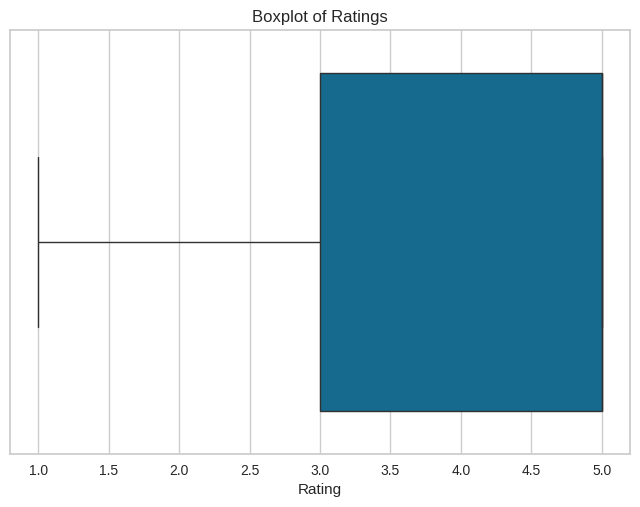

In [9]:
df_1['Rating'].quantile([0, 0.25, 0.5, 0.75, 1])
print("Minimum rating:", df_1['Rating'].min())
print("Maximum rating:", df_1['Rating'].max())

sns.boxplot(x=df_1['Rating'])
plt.title('Boxplot of Ratings')
plt.show()


## mengatasi missing value

In [10]:
df_1.isnull().sum()


,0
userId,0
productId,1
Rating,1
timestamp,1


In [11]:
df_1.duplicated().sum()


0

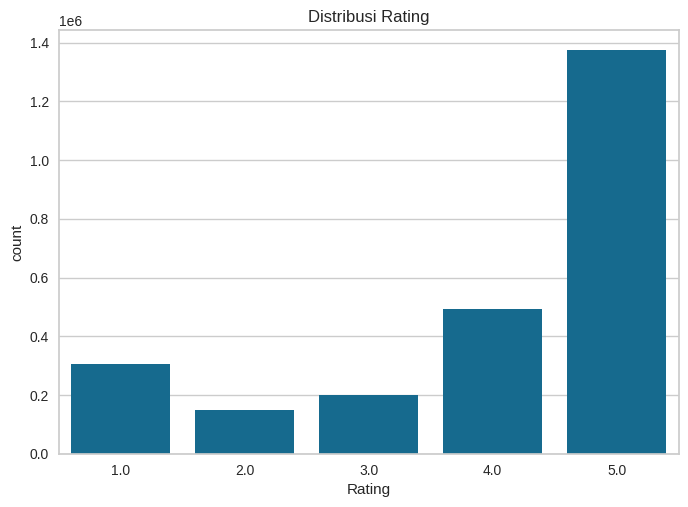

In [12]:
sns.countplot(x='Rating', data=df_1)
plt.title('Distribusi Rating')
plt.show()


In [13]:
# Melihat jumlah user unik
print("Jumlah user unik:", df_1['userId'].nunique())

# Melihat jumlah produk unik
print("Jumlah produk unik:", df_1['productId'].nunique())

# Melihat jenis nilai rating yang ada
print("Nilai rating unik:", df_1['Rating'].unique())
print("Jumlah nilai rating unik:", df_1['Rating'].nunique())

# (Opsional) Melihat jumlah timestamp unik
print("Jumlah timestamp unik:", df_1['timestamp'].nunique())


Jumlah user unik: 1671114
Jumlah produk unik: 139216
Nilai rating unik: [ 5.  1.  3.  2.  4. nan]
Jumlah nilai rating unik: 5
Jumlah timestamp unik: 5489


In [14]:
df_1.drop(['timestamp'], axis=1, inplace=True)

In [15]:
# Analisis aktivitas user berdasarkan jumlah produk yang diberi rating

# Hitung total rating yang diberikan tiap user
user_rating_count = df_1.groupby('userId')['Rating'].agg('count').reset_index()
user_rating_count.rename(columns={'Rating': 'total_rated_items'}, inplace=True)

# Urutkan user berdasarkan jumlah rating tertinggi
user_rating_count = user_rating_count.sort_values(by='total_rated_items', ascending=False)

# Tampilkan 5 user paling aktif
print("Top 5 pengguna dengan jumlah rating terbanyak:")
print(user_rating_count.head(), "\n")

# Ringkasan statistik deskriptif
summary_stats = user_rating_count['total_rated_items'].describe()
print("Ringkasan statistik jumlah rating per user:\n", summary_stats, "\n")

# Hitung distribusi kuantil untuk melihat persebaran jumlah rating
quantile_values = user_rating_count['total_rated_items'].quantile(np.linspace(0, 1, 101))

# Visualisasi hubungan antara kuantil dan nilai jumlah rating


Top 5 pengguna dengan jumlah rating terbanyak:
                 userId  total_rated_items
1298179   A5JLAU2ARJ0BO                449
1309068    A6FIAB28IS79                293
479597   A231WM2Z2JL0U3                252
1188748  A3OXHLG6DIBRW8                252
1306559   A680RUE1FDO8B                203 

Ringkasan statistik jumlah rating per user:
 count    1.671114e+06
mean     1.509717e+00
std      1.812886e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.490000e+02
Name: total_rated_items, dtype: float64 



# Collaberative filtering

---



In [16]:
from surprise import KNNWithMeans
from surprise import Dataset
from surprise import accuracy
from surprise import Reader
import os
from surprise.model_selection import train_test_split



Pada tahap ini, data rating diubah menjadi format yang dapat diproses oleh library Surprise menggunakan objek Reader. Skala penilaian yang digunakan adalah 1 hingga 5.
Dataset kemudian dibagi menjadi dua bagian, yaitu data latih (70%) dan data uji (30%), untuk mengevaluasi performa model.

Model yang digunakan adalah KNN With Means, yaitu algoritma collaborative filtering berbasis kemiripan antar item (item-based similarity). Model ini memperhitungkan rata-rata rating dari setiap item untuk menghasilkan prediksi yang lebih akurat.

Proses pelatihan dilakukan menggunakan data latih agar model dapat mengenali pola kesamaan antar item berdasarkan rating pengguna.

In [17]:
df_small = df_1.sample(5000, random_state=42)
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_small, reader)
trainset, testset = train_test_split(data, test_size=0.3, random_state=10)
algo = KNNWithMeans(k=3, sim_options={'name': 'pearson_baseline', 'user_based': False})
algo.fit(trainset)


Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.


In [18]:
test_pred = algo.test(testset)
test_pred

[Prediction(uid='A3S4CWOBD9FROW', iid='B000AAM1YI', r_ui=5.0, est=4.002571428571429, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='AA1R52JZF3A2Z', iid='B0014E5PHY', r_ui=4.0, est=4.002571428571429, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A3G6ELA95LCSCK', iid='B000068IHB', r_ui=1.0, est=4.002571428571429, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A3IL8XXB541BCO', iid='B000ENRQ3M', r_ui=3.0, est=4.002571428571429, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A2MZC2LG2MZH0S', iid='B000BYGOVO', r_ui=1.0, est=4.002571428571429, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A1NC5LB6H4X1VE', iid='B0002HA7FY', r_ui=5.0, est=4.002571428571429, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'}),
 Prediction(uid='A18SDUIH18SL

In [19]:
print("Item-based Model : Test Set")
accuracy.rmse(test_pred, verbose=True)

Item-based Model : Test Set
RMSE: 1.4422


1.442246489599439

# Model-based collaborative filtering system

---



Pada tahap ini, sistem rekomendasi dikembangkan menggunakan pendekatan model-based collaborative filtering dengan algoritma Singular Value Decomposition (SVD). Pendekatan ini berusaha menemukan representasi laten dari hubungan antara pengguna (user) dan produk (item) untuk mengidentifikasi pola preferensi tersembunyi.

In [20]:
new_data = df_small
ratings_matrix = new_data.pivot_table(values='Rating', index='userId', columns='productId', fill_value=0)

In [21]:
ratings_matrix.head()

productId,0972683275,1400532655,140053271X,1400599997,6465354276,9573212919,9575871979,9864216155,9888002198,B00000DM9W,...,B002BC89EE,B002BDU8TW,B002BDUAEK,B002BFA91C,B002BFZBUG,B002BG0SO4,B002BGFELQ,B002BGWNRO,B002BH3I9U,B002BH3Z8E
userId,,,,,,,,,,,,,,,,,,,,,
A02586451BC4KEH851D3A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A04523701ZTDV9AGO09EC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A08169603S0BGDPJ161BY,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A101243KMUIJC0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1022CFAJGLFH,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
X = ratings_matrix.T
X.head()

userId,A02586451BC4KEH851D3A,A04523701ZTDV9AGO09EC,A08169603S0BGDPJ161BY,A101243KMUIJC0,A1022CFAJGLFH,A104OXQW9ZVQW5,A105WPP22KV4OT,A1060TU3IGU2UJ,A108C2HKYXRGQK,A109NS9UI0MN16,...,AZTGX6VAQSJB1,AZTZQ049W5XZX,AZUG7T2XYSI7A,AZUKWJBWDFH7N,AZUMS9FLOTFOY,AZYJUN7O8SBKN,AZYTAHQLALUW3,AZYTK5M9J0HHB,AZZ109YL80ZX0,AZZ2DEE2NTIM7
productId,,,,,,,,,,,,,,,,,,,,,
0972683275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1400532655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
140053271X,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1400599997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6465354276,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
X1 =X

In [24]:
df_rec = ratings_matrix.T
from sklearn.decomposition import TruncatedSVD
SVD = TruncatedSVD(n_components=10)
decomposed_matrix = SVD.fit_transform(X)



In [25]:
correlation_matrix = np.corrcoef(decomposed_matrix)


In [26]:
X.index[90]

'B00004WCI8'

Untuk menghasilkan rekomendasi, dipilih satu produk tertentu (misalnya B00000K135) sebagai acuan. Sistem kemudian mencari produk lain yang memiliki tingkat korelasi tinggi (lebih dari 0.65) terhadap produk tersebut. Produk dengan korelasi tinggi diasumsikan memiliki kesamaan karakteristik dan kemungkinan disukai oleh pengguna yang sama.

In [28]:
i = "B00004WCI8"
product_names = list(X.index)
product_ID = product_names.index(i)


In [29]:
correlation_product_ID = correlation_matrix[product_ID]
correlation_product_ID.shape


(3824,)

HASIL REKOMENDASI

In [30]:
Recommend = list(X.index[correlation_product_ID > 0.65])

# Removes the item already bought by the customer
Recommend.remove(i)

Recommend[0:24]



['B00000J1V5',
 'B00000J4FS',
 'B00000JBHP',
 'B00000JDGQ',
 'B00001SIKD',
 'B0000300GE',
 'B00004RG6K',
 'B00004SYVH',
 'B00004TDAL',
 'B00004TDL2',
 'B00004TZGM',
 'B00004Z75J',
 'B00004ZCJE',
 'B000051123',
 'B000051249',
 'B00005A3LN',
 'B00005AC8W',
 'B00005MIS8',
 'B00005NIMN',
 'B00005QSRF',
 'B00005RG4N',
 'B00005UKXM',
 'B000063574',
 'B0000645RH']

In [32]:

import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt

# Melakukan rekonstruksi matriks dari hasil dekomposisi
X_pred = np.dot(SVD.transform(X), SVD.components_)

# Menghitung RMSE antara matriks asli dan hasil prediksi
rmse_svd = sqrt(mean_squared_error(X, X_pred))
print(f"RMSE (SVD): {rmse_svd:.4f}")



RMSE (SVD): 0.0672
